# Object Detection and Tracking Demo

This notebook demonstrates how to use the `detector` and `tracker` modules for object detection and tracking in video sequences.


In [9]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
from detector import ObjectDetector
from tracker import ObjectTracker


## 1. Object Detection

First, let's set up the detector with custom parameters.


In [10]:
# Initialize detector
detector = ObjectDetector(
    history=500,
    dist_threshold=800,
    min_area=30,
    max_area=100000
)

print("Detector initialized!")
print(f"Min area: {detector.min_area}")
print(f"Max area: {detector.max_area}")


Detector initialized!
Min area: 30
Max area: 100000


In [11]:
# Load frames
INPUT_FOLDER = "../data/images/videoplayback/blurred_frames"
files = sorted(glob.glob(f"{INPUT_FOLDER}/*.png"))
if not files:
    files = sorted(glob.glob(f"{INPUT_FOLDER}/*.jpg"))

print(f"Found {len(files)} frames")


Found 387 frames


In [12]:
# Detect objects in frames
all_detections = []

for i, file_path in enumerate(files[:50]):
    frame = cv2.imread(file_path)
    if frame is None:
        continue
    
    detections = detector.detect(frame)
    
    for cx, cy, w, h in detections:
        all_detections.append([i, cx, cy, w, h])
    
    if i % 10 == 0:
        print(f"Frame {i}: {len(detections)} objects")

print(f"\nTotal detections: {len(all_detections)}")


Frame 0: 0 objects
Frame 10: 1 objects
Frame 20: 1 objects
Frame 30: 2 objects
Frame 40: 5 objects

Total detections: 132


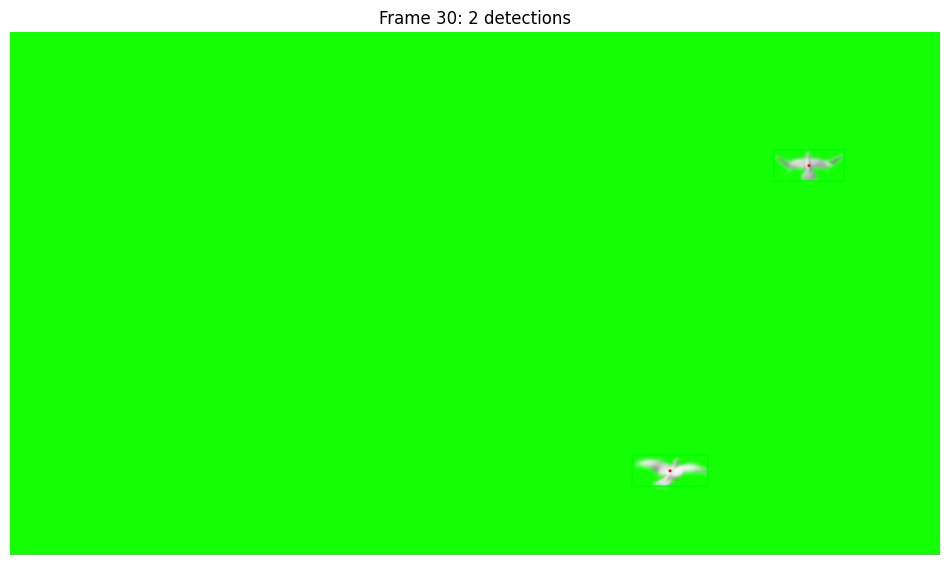

In [13]:
# Visualize sample frame
sample_idx = 30
frame = cv2.imread(files[sample_idx])
detections = detector.detect(frame)

vis_frame = frame.copy()
for cx, cy, w, h in detections:
    x, y = int(cx - w/2), int(cy - h/2)
    cv2.rectangle(vis_frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.circle(vis_frame, (cx, cy), 3, (0, 0, 255), -1)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
plt.title(f"Frame {sample_idx}: {len(detections)} detections")
plt.axis('off')
plt.show()


## 2. Object Tracking

Now let's track the detected objects across frames.


In [14]:
# Initialize tracker
tracker = ObjectTracker(
    max_distance=30.0,
    min_hits=3,
    max_age=30
)

print("Tracker initialized!")
print(f"Max distance: {tracker.max_distance}")
print(f"Min hits: {tracker.min_hits}")


Tracker initialized!
Max distance: 30.0
Min hits: 3


In [15]:
# Run detection and tracking
detector.reset()
tracker.reset()

for i, file_path in enumerate(files[:50]):
    frame = cv2.imread(file_path)
    if frame is None:
        continue
    
    detections = detector.detect(frame)
    tracks = tracker.update(detections)
    confirmed = tracker.get_confirmed_tracks()
    
    if i % 10 == 0:
        print(f"Frame {i}: {len(detections)} detections, {len(confirmed)} confirmed tracks")

print(f"\nTotal unique tracks: {tracker.next_id}")


Frame 0: 0 detections, 0 confirmed tracks
Frame 10: 1 detections, 0 confirmed tracks
Frame 20: 1 detections, 2 confirmed tracks
Frame 30: 2 detections, 4 confirmed tracks
Frame 40: 5 detections, 5 confirmed tracks

Total unique tracks: 46


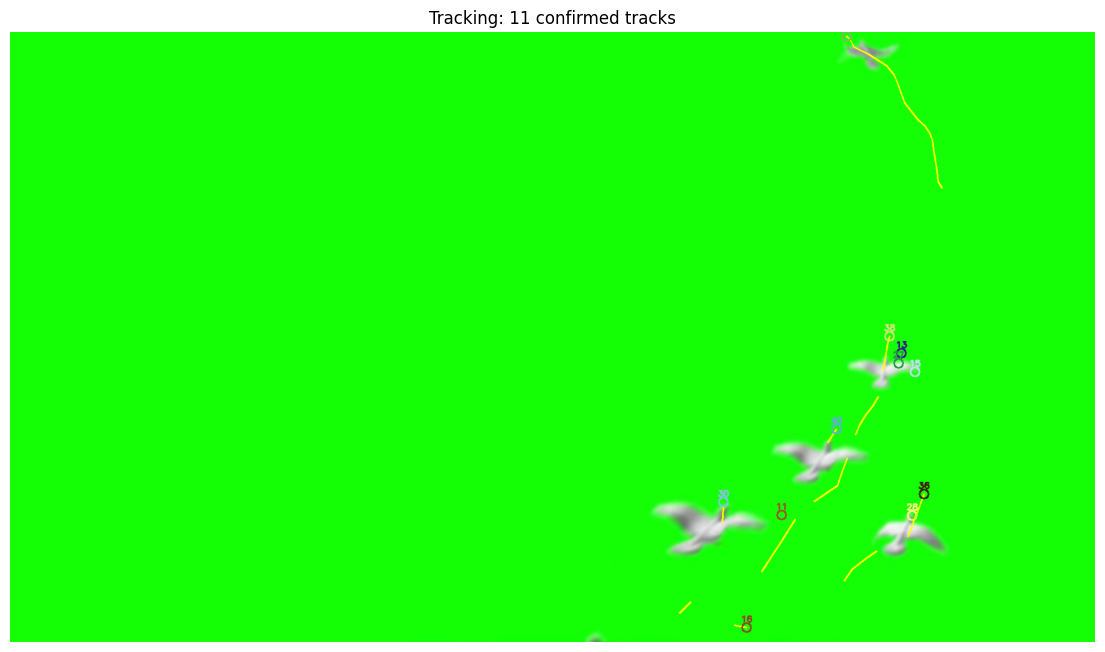

In [16]:
# Visualize tracks on a frame
vis_frame = cv2.imread(files[45])
confirmed = tracker.get_confirmed_tracks()

for track in confirmed:
    # Draw trajectory
    if len(track.history) > 1:
        pts = np.array(track.history, np.int32).reshape((-1, 1, 2))
        cv2.polylines(vis_frame, [pts], False, (0, 255, 255), 2)
    
    # Draw current position
    color = ((track.id * 50) % 255, (track.id * 100) % 255, (track.id * 200) % 255)
    cx, cy = int(track.prediction[0]), int(track.prediction[1])
    cv2.circle(vis_frame, (cx, cy), 8, color, 2)
    cv2.putText(vis_frame, str(track.id), (cx-10, cy-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
plt.title(f"Tracking: {len(confirmed)} confirmed tracks")
plt.axis('off')
plt.show()


## 3. Complete Pipeline

Here's a complete function that processes video and saves output.


In [ ]:
def process_video(input_folder, output_video, num_frames=None):
    """Complete detection and tracking pipeline."""
    
    detector = ObjectDetector(history=1000, min_area=30, max_area=100000)
    tracker = ObjectTracker(max_distance=100, min_hits=3, max_age=300)
    
    files = sorted(glob.glob(f"{input_folder}/*.png"))
    if not files:
        files = sorted(glob.glob(f"{input_folder}/*.jpg"))
    
    if num_frames:
        files = files[:num_frames]
    
    sample = cv2.imread(files[0])
    h, w = sample.shape[:2]
    writer = cv2.VideoWriter(output_video, cv2.VideoWriter_fourcc(*'mp4v'), 30, (w, h))
    
    print(f"Processing {len(files)} frames...")
    
    for i, file_path in enumerate(files):
        frame = cv2.imread(file_path)
        if frame is None:
            continue
        
        detections = detector.detect(frame)
        tracks = tracker.update(detections)
        confirmed = tracker.get_confirmed_tracks()
        
        # Draw tracks
        for track in confirmed:
            if len(track.history) > 1:
                pts = np.array(track.history, np.int32).reshape((-1, 1, 2))
                cv2.polylines(frame, [pts], False, (0, 255, 255), 2)
            
            color = ((track.id * 50) % 255, (track.id * 100) % 255, (track.id * 200) % 255)
            cx, cy = int(track.prediction[0]), int(track.prediction[1])
            cv2.circle(frame, (cx, cy), 8, color, 2)
            cv2.putText(frame, str(track.id), (cx-10, cy-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        cv2.putText(frame, f"Frame: {i}", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(frame, f"Tracks: {len(confirmed)}", (10, 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        writer.write(frame)
        
        if i % 20 == 0:
            print(f"  Frame {i}/{len(files)}")
    
    writer.release()
    print(f"\nDone! Video: {output_video}")
    print(f"Total unique tracks: {tracker.next_id}")

# Example usage (uncomment to run):
# process_video("../data/images/bees_short/blurred_frames", "tracking_demo.mp4", num_frames=300)


Processing 300 frames...
  Frame 0/300
  Frame 20/300
  Frame 40/300
  Frame 60/300
  Frame 80/300
  Frame 100/300
  Frame 120/300
  Frame 140/300
  Frame 160/300
  Frame 180/300
  Frame 200/300
  Frame 220/300
  Frame 240/300
  Frame 260/300
  Frame 280/300

Done! Video: tracking_demo.mp4
Total unique tracks: 540
